# 📈 NEXUS Stock AI — Phase 26: Financial Simulation & Vectorized Backtesting
## Multi-Modal Strategy Evaluation Across 2023 Out-of-Sample Market Regime

**Objective:** Evaluate the financial viability, risk-adjusted performance, and drawdown mitigation of the champion **NEXUS Multi-Modal XGBoost Strategy** on the **2023 Out-of-Sample Test set** (1,736 trading sessions across 9 stocks).

### 🔬 Phases & Framework Implemented:
1. **Realistic Market Friction Model:**
   - **Transaction Costs:** Deduct 10 basis points (0.10%) per trade on position entry ($0 \rightarrow 1$) and exit ($1 \rightarrow 0$) to account for real-world exchange fees, slippage, and commissions.
   - **Strict Zero-Leakage:** Signal for session $t+1$ is generated strictly at market close $t$ (4:00 PM cutoff). The trade captures close-to-close forward return $R_{t+1} = \frac{\text{close}_{t+1} - \text{close}_t}{\text{close}_t}$.
2. **Threshold Conviction Sweep:**
   - Absolute Thresholds: $P(\text{UP}) \ge 0.50$, $0.51$, $0.52$.
   - Dynamic Relative Hurdle: $P(\text{UP}) \ge \text{Median}_t(P(\text{UP}))$ (cross-sectional ranking).
3. **Benchmark & Portfolio Attribution:**
   - Equal-weighted portfolio across 9 mega-cap equities (`AAPL`, `AMD`, `AMZN`, `GOOGL`, `JPM`, `MSFT`, `NFLX`, `NVDA`, `TSLA`).
   - Direct comparison against the **Equal-Weighted Buy & Hold Benchmark** over 2023.
   - Key metrics: Cumulative Return, Annualized Return (CAGR), Volatility, Sharpe Ratio, Maximum Drawdown (MDD), Win Rate, and Calmar Ratio.
4. **Visualizations & Production Module:**
   - 2-Panel plot: Cumulative Equity Curve & Underwater Drawdown Profile saved to `backtest_equity_curve.png`.
   - Results exported to `backtest_results.json` and standalone engine in `src/backtest/engine.py`.

### ⚙️ Step 1: Environment Setup & Data Loading

In [1]:
# Install dependencies
%pip install -q xgboost scikit-learn joblib pyarrow matplotlib seaborn

import os
import sys
import time
import json
import shutil
import zipfile
import base64
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import xgboost as xgb

# Mount Google Drive if in Colab
try:
    from google.colab import drive
    print("Mounting Google Drive at /content/drive...")
    drive.mount("/content/drive")
    print("✓ Google Drive mounted successfully.")
except Exception as e:
    print(f"Drive mount note: {e}")

# Resolve paths
GDRIVE_DIR = "/content/drive/MyDrive/NEXUS_Stock_AI/data"
LOCAL_DIR = "./data"

def resolve_path(filename):
    candidates = [
        os.path.join(GDRIVE_DIR, filename),
        os.path.join(LOCAL_DIR, filename),
        os.path.join("/content/drive/MyDrive/NEXUS_Stock_AI/models", filename),
        os.path.join("./models", filename),
        filename
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    return candidates[0]

DATASET_PATH = resolve_path("model_dataset_v1.parquet")
print(f"Target Dataset Path: {DATASET_PATH} (Exists: {os.path.exists(DATASET_PATH)})")

# Auto-Scaffold src/backtest package
os.makedirs("src/backtest", exist_ok=True)
init_b64 = "ZnJvbSAuZW5naW5lIGltcG9ydCBWZWN0b3JpemVkQmFja3Rlc3RlcgoKX19hbGxfXyA9IFsiVmVjdG9yaXplZEJhY2t0ZXN0ZXIiXQo="
engine_b64 = "IyEvdXNyL2Jpbi9lbnYgcHl0aG9uMwoiIiIKTkVYVVMgU3RvY2sgQUkg4oCUIFZlY3Rvcml6ZWQgQmFja3Rlc3RpbmcgJiBGaW5hbmNpYWwgU2ltdWxhdGlvbiBFbmdpbmUgKFBoYXNlIDI2KQpQcm92aWRlcyBpbnN0aXR1dGlvbmFsLWdyYWRlIHBlcmZvcm1hbmNlIGF0dHJpYnV0aW9uLCB0cmFuc2FjdGlvbiBjb3N0IG1vZGVsaW5nLApkcmF3ZG93biB0cmFja2luZywgYW5kIGJlbmNobWFyayBjb21wYXJpc29uIGZvciBkaXJlY3Rpb25hbCBlcXVpdHkgc3RyYXRlZ2llcy4KIiIiCgppbXBvcnQgb3MKaW1wb3J0IGpzb24KZnJvbSB0eXBpbmcgaW1wb3J0IERpY3QsIEFueSwgTGlzdCwgVW5pb24sIE9wdGlvbmFsCmltcG9ydCBudW1weSBhcyBucAppbXBvcnQgcGFuZGFzIGFzIHBkCmltcG9ydCBtYXRwbG90bGliLnB5cGxvdCBhcyBwbHQKCgpjbGFzcyBWZWN0b3JpemVkQmFja3Rlc3RlcjoKICAgICIiIgogICAgVmVjdG9yaXplZCBlcXVpdHkgcG9ydGZvbGlvIGJhY2t0ZXN0aW5nIGFuZCBhdHRyaWJ1dGlvbiBlbmdpbmUuCiAgICBTdXBwb3J0cyBkeW5hbWljIHRocmVzaG9sZHMsIHRyYW5zYWN0aW9uIGZyaWN0aW9uIChicHMpLCBhbmQgZXF1YWwtd2VpZ2h0ZWQgcG9ydGZvbGlvIGFnZ3JlZ2F0aW9uLgogICAgIiIiCgogICAgZGVmIF9faW5pdF9fKHNlbGYsIGNvc3RfYnBzOiBmbG9hdCA9IDEwLjAsIHJpc2tfZnJlZV9yYXRlOiBmbG9hdCA9IDAuMCk6CiAgICAgICAgIiIiCiAgICAgICAgQXJnczoKICAgICAgICAgICAgY29zdF9icHM6IFRyYW5zYWN0aW9uIGNvc3QgaW4gYmFzaXMgcG9pbnRzICgxMCBicHMgPSAwLjEwJSA9IDAuMDAxMCkgZGVkdWN0ZWQgb24gZW50cnkgJiBleGl0LgogICAgICAgICAgICByaXNrX2ZyZWVfcmF0ZTogQW5udWFsaXplZCByaXNrLWZyZWUgcmF0ZSBmb3IgU2hhcnBlIHJhdGlvIGNhbGN1bGF0aW9uIChkZWZhdWx0IDAuMCkuCiAgICAgICAgIiIiCiAgICAgICAgc2VsZi5jb3N0X3JhdGUgPSBjb3N0X2JwcyAvIDEwMDAwLjAgICMgMTAgYnBzID0gMC4wMDEwCiAgICAgICAgc2VsZi5yaXNrX2ZyZWVfcmF0ZSA9IHJpc2tfZnJlZV9yYXRlCgogICAgZGVmIGNvbXB1dGVfZm9yd2FyZF9yZXR1cm5zKHNlbGYsIGRmOiBwZC5EYXRhRnJhbWUpIC0+IHBkLkRhdGFGcmFtZToKICAgICAgICAiIiIKICAgICAgICBDb21wdXRlcyBsZWFrLWZyZWUgZm9yd2FyZCAxLWRheSBjbG9zZS10by1jbG9zZSByZXR1cm5zIHBlciB0aWNrZXI6CiAgICAgICAgUl9mb3J3YXJkX3t0KzF9ID0gKGNsb3NlX3t0KzF9IC0gY2xvc2VfdCkgLyBjbG9zZV90LgogICAgICAgICIiIgogICAgICAgIGRmID0gZGYuY29weSgpCiAgICAgICAgaWYgImZvcndhcmRfcmV0dXJuXzFkIiBub3QgaW4gZGYuY29sdW1uczoKICAgICAgICAgICAgZGZbImZvcndhcmRfcmV0dXJuXzFkIl0gPSBkZi5ncm91cGJ5KCJzdG9ja19zeW1ib2wiKVsiY2xvc2UiXS5wY3RfY2hhbmdlKDEpLnNoaWZ0KC0xKQogICAgICAgICAgICAjIEZpbGwgdGVybWluYWwgcm93IHBlciB0aWNrZXIgd2l0aCAwLjAKICAgICAgICAgICAgZGZbImZvcndhcmRfcmV0dXJuXzFkIl0gPSBkZlsiZm9yd2FyZF9yZXR1cm5fMWQiXS5maWxsbmEoMC4wKQogICAgICAgIHJldHVybiBkZgoKICAgIGRlZiBydW5fYmFja3Rlc3QoCiAgICAgICAgc2VsZiwKICAgICAgICBkZjogcGQuRGF0YUZyYW1lLAogICAgICAgIHByb2JfY29sOiBzdHIgPSAidXBfcHJvYmFiaWxpdHkiLAogICAgICAgIHRocmVzaG9sZDogVW5pb25bZmxvYXQsIHN0cl0gPSAwLjUwCiAgICApIC0+IERpY3Rbc3RyLCBBbnldOgogICAgICAgICIiIgogICAgICAgIEV4ZWN1dGVzIHZlY3Rvcml6ZWQgYmFja3Rlc3QgZm9yIGEgZ2l2ZW4gcHJvYmFiaWxpdHkgdGhyZXNob2xkLgoKICAgICAgICBBcmdzOgogICAgICAgICAgICBkZjogRGF0YUZyYW1lIGNvbnRhaW5pbmcgWydkYXRlJywgJ3N0b2NrX3N5bWJvbCcsICdjbG9zZScsIHByb2JfY29sLCAnZm9yd2FyZF9yZXR1cm5fMWQnXQogICAgICAgICAgICBwcm9iX2NvbDogTmFtZSBvZiBjb2x1bW4gY29udGFpbmluZyBQKFVQKQogICAgICAgICAgICB0aHJlc2hvbGQ6IEZsb2F0IChlLmcuIDAuNTAsIDAuNTEpIG9yICJtZWRpYW4iIGZvciBjcm9zcy1zZWN0aW9uYWwgbWVkaWFuIHRocmVzaG9sZC4KCiAgICAgICAgUmV0dXJuczoKICAgICAgICAgICAgRGljdGlvbmFyeSB3aXRoIHBvcnRmb2xpbyBlcXVpdHkgc2VyaWVzLCBkYWlseSByZXR1cm5zLCBhbmQgcGVyZm9ybWFuY2UgbWV0cmljcy4KICAgICAgICAiIiIKICAgICAgICBkZiA9IHNlbGYuY29tcHV0ZV9mb3J3YXJkX3JldHVybnMoZGYpCiAgICAgICAgZGYgPSBkZi5zb3J0X3ZhbHVlcyhbImRhdGUiLCAic3RvY2tfc3ltYm9sIl0pLnJlc2V0X2luZGV4KGRyb3A9VHJ1ZSkKCiAgICAgICAgIyAxLiBEZXRlcm1pbmUgUG9zaXRpb24gU2lnbmFsCiAgICAgICAgaWYgaXNpbnN0YW5jZSh0aHJlc2hvbGQsIHN0cikgYW5kIHRocmVzaG9sZC5sb3dlcigpID09ICJtZWRpYW4iOgogICAgICAgICAgICAjIER5bmFtaWMgY3Jvc3Mtc2VjdGlvbmFsIG1lZGlhbiBwZXIgZGF0ZQogICAgICAgICAgICBkYWlseV9tZWRpYW5zID0gZGYuZ3JvdXBieSgiZGF0ZSIpW3Byb2JfY29sXS50cmFuc2Zvcm0oIm1lZGlhbiIpCiAgICAgICAgICAgIGRmWyJwb3NpdGlvbiJdID0gKGRmW3Byb2JfY29sXSA+PSBkYWlseV9tZWRpYW5zKS5hc3R5cGUoaW50KQogICAgICAgIGVsc2U6CiAgICAgICAgICAgIHRocmVzaF92YWwgPSBmbG9hdCh0aHJlc2hvbGQpCiAgICAgICAgICAgIGRmWyJwb3NpdGlvbiJdID0gKGRmW3Byb2JfY29sXSA+PSB0aHJlc2hfdmFsKS5hc3R5cGUoaW50KQoKICAgICAgICAjIDIuIFRyYW5zYWN0aW9uIENvc3RzIG9uIFBvc2l0aW9uIFRyYW5zaXRpb25zCiAgICAgICAgIyBTaGlmdCBwb3NpdGlvbiBwZXIgdGlja2VyIHRvIGRldGVjdCBlbnRyeSAoMCAtPiAxKSBhbmQgZXhpdCAoMSAtPiAwKQogICAgICAgIGRmWyJwcmV2X3Bvc2l0aW9uIl0gPSBkZi5ncm91cGJ5KCJzdG9ja19zeW1ib2wiKVsicG9zaXRpb24iXS5zaGlmdCgxKS5maWxsbmEoMCkuYXN0eXBlKGludCkKICAgICAgICBkZlsidHJhZGVfYWN0aW9uIl0gPSAoZGZbInBvc2l0aW9uIl0gIT0gZGZbInByZXZfcG9zaXRpb24iXSkuYXN0eXBlKGludCkKICAgICAgICBkZlsidHJhbnNfY29zdCJdID0gZGZbInRyYWRlX2FjdGlvbiJdICogc2VsZi5jb3N0X3JhdGUKCiAgICAgICAgIyAzLiBOZXQgU3RvY2sgUmV0dXJuCiAgICAgICAgZGZbIm5ldF9yZXR1cm4iXSA9IGRmWyJwb3NpdGlvbiJdICogZGZbImZvcndhcmRfcmV0dXJuXzFkIl0gLSBkZlsidHJhbnNfY29zdCJdCgogICAgICAgICMgNC4gRXF1YWwtV2VpZ2h0ZWQgUG9ydGZvbGlvIEFnZ3JlZ2F0aW9uIHBlciBUcmFkaW5nIERhdGUKICAgICAgICBwb3J0Zm9saW9fZGFpbHkgPSBkZi5ncm91cGJ5KCJkYXRlIikuYWdnKAogICAgICAgICAgICBzdHJhdF9yZXR1cm49KCJuZXRfcmV0dXJuIiwgIm1lYW4iKSwKICAgICAgICAgICAgYmVuY2hfcmV0dXJuPSgiZm9yd2FyZF9yZXR1cm5fMWQiLCAibWVhbiIpLAogICAgICAgICAgICBhY3RpdmVfc3RvY2tzPSgicG9zaXRpb24iLCAic3VtIiksCiAgICAgICAgICAgIHRvdGFsX3N0b2Nrcz0oInBvc2l0aW9uIiwgImNvdW50IiksCiAgICAgICAgICAgIHRyYWRlc190b2RheT0oInRyYWRlX2FjdGlvbiIsICJzdW0iKQogICAgICAgICkucmVzZXRfaW5kZXgoKQoKICAgICAgICAjIERlZHVjdCBpbml0aWFsIGJlbmNobWFyayBlbnRyeSBjb3N0IG9uIGRheSAwCiAgICAgICAgaWYgbGVuKHBvcnRmb2xpb19kYWlseSkgPiAwOgogICAgICAgICAgICBwb3J0Zm9saW9fZGFpbHkubG9jWzAsICJiZW5jaF9yZXR1cm4iXSAtPSBzZWxmLmNvc3RfcmF0ZQoKICAgICAgICAjIDUuIEN1bXVsYXRpdmUgRXF1aXR5IEN1cnZlcwogICAgICAgIHBvcnRmb2xpb19kYWlseVsic3RyYXRfZXF1aXR5Il0gPSAoMS4wICsgcG9ydGZvbGlvX2RhaWx5WyJzdHJhdF9yZXR1cm4iXSkuY3VtcHJvZCgpCiAgICAgICAgcG9ydGZvbGlvX2RhaWx5WyJiZW5jaF9lcXVpdHkiXSA9ICgxLjAgKyBwb3J0Zm9saW9fZGFpbHlbImJlbmNoX3JldHVybiJdKS5jdW1wcm9kKCkKCiAgICAgICAgIyA2LiBEcmF3ZG93biBDYWxjdWxhdGlvbgogICAgICAgIHBvcnRmb2xpb19kYWlseVsic3RyYXRfcGVhayJdID0gcG9ydGZvbGlvX2RhaWx5WyJzdHJhdF9lcXVpdHkiXS5jdW1tYXgoKQogICAgICAgIHBvcnRmb2xpb19kYWlseVsic3RyYXRfZHJhd2Rvd24iXSA9IChwb3J0Zm9saW9fZGFpbHlbInN0cmF0X2VxdWl0eSJdIC0gcG9ydGZvbGlvX2RhaWx5WyJzdHJhdF9wZWFrIl0pIC8gcG9ydGZvbGlvX2RhaWx5WyJzdHJhdF9wZWFrIl0KCiAgICAgICAgcG9ydGZvbGlvX2RhaWx5WyJiZW5jaF9wZWFrIl0gPSBwb3J0Zm9saW9fZGFpbHlbImJlbmNoX2VxdWl0eSJdLmN1bW1heCgpCiAgICAgICAgcG9ydGZvbGlvX2RhaWx5WyJiZW5jaF9kcmF3ZG93biJdID0gKHBvcnRmb2xpb19kYWlseVsiYmVuY2hfZXF1aXR5Il0gLSBwb3J0Zm9saW9fZGFpbHlbImJlbmNoX3BlYWsiXSkgLyBwb3J0Zm9saW9fZGFpbHlbImJlbmNoX3BlYWsiXQoKICAgICAgICAjIDcuIFN1bW1hcnkgTWV0cmljcwogICAgICAgIHN0cmF0X21ldHJpY3MgPSBzZWxmLmNvbXB1dGVfbWV0cmljcygKICAgICAgICAgICAgcmV0dXJucz1wb3J0Zm9saW9fZGFpbHlbInN0cmF0X3JldHVybiJdLAogICAgICAgICAgICBlcXVpdHk9cG9ydGZvbGlvX2RhaWx5WyJzdHJhdF9lcXVpdHkiXSwKICAgICAgICAgICAgZHJhd2Rvd249cG9ydGZvbGlvX2RhaWx5WyJzdHJhdF9kcmF3ZG93biJdLAogICAgICAgICAgICB0cmFkZXM9aW50KGRmWyJ0cmFkZV9hY3Rpb24iXS5zdW0oKSkKICAgICAgICApCgogICAgICAgIGJlbmNoX21ldHJpY3MgPSBzZWxmLmNvbXB1dGVfbWV0cmljcygKICAgICAgICAgICAgcmV0dXJucz1wb3J0Zm9saW9fZGFpbHlbImJlbmNoX3JldHVybiJdLAogICAgICAgICAgICBlcXVpdHk9cG9ydGZvbGlvX2RhaWx5WyJiZW5jaF9lcXVpdHkiXSwKICAgICAgICAgICAgZHJhd2Rvd249cG9ydGZvbGlvX2RhaWx5WyJiZW5jaF9kcmF3ZG93biJdLAogICAgICAgICAgICB0cmFkZXM9aW50KGRmWyJzdG9ja19zeW1ib2wiXS5udW5pcXVlKCkpCiAgICAgICAgKQoKICAgICAgICByZXR1cm4gewogICAgICAgICAgICAidGhyZXNob2xkIjogdGhyZXNob2xkLAogICAgICAgICAgICAicG9ydGZvbGlvX2RhaWx5IjogcG9ydGZvbGlvX2RhaWx5LAogICAgICAgICAgICAic3RvY2tfdHJhZGVzX2RmIjogZGYsCiAgICAgICAgICAgICJzdHJhdF9tZXRyaWNzIjogc3RyYXRfbWV0cmljcywKICAgICAgICAgICAgImJlbmNoX21ldHJpY3MiOiBiZW5jaF9tZXRyaWNzCiAgICAgICAgfQoKICAgIGRlZiBjb21wdXRlX21ldHJpY3MoCiAgICAgICAgc2VsZiwKICAgICAgICByZXR1cm5zOiBwZC5TZXJpZXMsCiAgICAgICAgZXF1aXR5OiBwZC5TZXJpZXMsCiAgICAgICAgZHJhd2Rvd246IHBkLlNlcmllcywKICAgICAgICB0cmFkZXM6IGludAogICAgKSAtPiBEaWN0W3N0ciwgZmxvYXRdOgogICAgICAgICIiIkNhbGN1bGF0ZXMgaW5zdGl0dXRpb25hbCBmaW5hbmNpYWwgcGVyZm9ybWFuY2UgbWV0cmljcy4iIiIKICAgICAgICBuX2RheXMgPSBsZW4ocmV0dXJucykKICAgICAgICBpZiBuX2RheXMgPT0gMDoKICAgICAgICAgICAgcmV0dXJuIHt9CgogICAgICAgIHRvdGFsX3JldHVybiA9IGZsb2F0KGVxdWl0eS5pbG9jWy0xXSAtIDEuMCkKICAgICAgICBjYWdyID0gZmxvYXQoKGVxdWl0eS5pbG9jWy0xXSkgKiogKDI1Mi4wIC8gbl9kYXlzKSAtIDEuMCkgaWYgZXF1aXR5Lmlsb2NbLTFdID4gMCBlbHNlIC0xLjAKICAgICAgICBkYWlseV9tZWFuID0gZmxvYXQocmV0dXJucy5tZWFuKCkpCiAgICAgICAgZGFpbHlfc3RkID0gZmxvYXQocmV0dXJucy5zdGQoKSkKCiAgICAgICAgYW5uX3ZvbCA9IGZsb2F0KGRhaWx5X3N0ZCAqIG5wLnNxcnQoMjUyLjApKQogICAgICAgIHNoYXJwZSA9IGZsb2F0KChkYWlseV9tZWFuICogMjUyLjAgLSBzZWxmLnJpc2tfZnJlZV9yYXRlKSAvIGFubl92b2wpIGlmIGFubl92b2wgPiAwIGVsc2UgMC4wCgogICAgICAgIG1heF9kZCA9IGZsb2F0KGFicyhkcmF3ZG93bi5taW4oKSkpCiAgICAgICAgY2FsbWFyID0gZmxvYXQoY2FnciAvIG1heF9kZCkgaWYgbWF4X2RkID4gMCBlbHNlIDAuMAoKICAgICAgICB3aW5fcmF0ZSA9IGZsb2F0KChyZXR1cm5zID4gMCkubWVhbigpKQoKICAgICAgICByZXR1cm4gewogICAgICAgICAgICAiY3VtdWxhdGl2ZV9yZXR1cm4iOiB0b3RhbF9yZXR1cm4sCiAgICAgICAgICAgICJhbm51YWxpemVkX3JldHVybiI6IGNhZ3IsCiAgICAgICAgICAgICJhbm51YWxpemVkX3ZvbGF0aWxpdHkiOiBhbm5fdm9sLAogICAgICAgICAgICAic2hhcnBlX3JhdGlvIjogc2hhcnBlLAogICAgICAgICAgICAibWF4X2RyYXdkb3duIjogbWF4X2RkLAogICAgICAgICAgICAiY2FsbWFyX3JhdGlvIjogY2FsbWFyLAogICAgICAgICAgICAiZGFpbHlfd2luX3JhdGUiOiB3aW5fcmF0ZSwKICAgICAgICAgICAgInRvdGFsX3RyYWRlcyI6IHRyYWRlcwogICAgICAgIH0KCiAgICBkZWYgcnVuX3RocmVzaG9sZF9zd2VlcCgKICAgICAgICBzZWxmLAogICAgICAgIGRmOiBwZC5EYXRhRnJhbWUsCiAgICAgICAgcHJvYl9jb2w6IHN0ciA9ICJ1cF9wcm9iYWJpbGl0eSIsCiAgICAgICAgdGhyZXNob2xkczogT3B0aW9uYWxbTGlzdFtVbmlvbltmbG9hdCwgc3RyXV1dID0gTm9uZQogICAgKSAtPiBwZC5EYXRhRnJhbWU6CiAgICAgICAgIiIiUnVucyBjb21wYXJhdGl2ZSBzd2VlcCBhY3Jvc3MgbXVsdGlwbGUgY29udmljdGlvbiB0aHJlc2hvbGRzLiIiIgogICAgICAgIGlmIHRocmVzaG9sZHMgaXMgTm9uZToKICAgICAgICAgICAgdGhyZXNob2xkcyA9IFswLjUwLCAwLjUxLCAwLjUyLCAibWVkaWFuIl0KCiAgICAgICAgcmVjb3JkcyA9IFtdCiAgICAgICAgZm9yIHRoIGluIHRocmVzaG9sZHM6CiAgICAgICAgICAgIHJlcyA9IHNlbGYucnVuX2JhY2t0ZXN0KGRmLCBwcm9iX2NvbD1wcm9iX2NvbCwgdGhyZXNob2xkPXRoKQogICAgICAgICAgICBtID0gcmVzWyJzdHJhdF9tZXRyaWNzIl0KICAgICAgICAgICAgbmFtZSA9IGYiTkVYVVMgQUkgKFAgPj0ge3RoOi4yZn0pIiBpZiBpc2luc3RhbmNlKHRoLCAoaW50LCBmbG9hdCkpIGVsc2UgZiJORVhVUyBBSSAoe3RoLmNhcGl0YWxpemUoKX0pIgogICAgICAgICAgICByZWNvcmRzLmFwcGVuZCh7CiAgICAgICAgICAgICAgICAiU3RyYXRlZ3kiOiBuYW1lLAogICAgICAgICAgICAgICAgIkN1bXVsYXRpdmUgUmV0dXJuIjogZiJ7bVsnY3VtdWxhdGl2ZV9yZXR1cm4nXSAqIDEwMDorLjJmfSUiLAogICAgICAgICAgICAgICAgIkFubnVhbGl6ZWQgUmV0dXJuIjogZiJ7bVsnYW5udWFsaXplZF9yZXR1cm4nXSAqIDEwMDorLjJmfSUiLAogICAgICAgICAgICAgICAgIkFubnVhbGl6ZWQgVm9sIjogZiJ7bVsnYW5udWFsaXplZF92b2xhdGlsaXR5J10gKiAxMDA6LjJmfSUiLAogICAgICAgICAgICAgICAgIlNoYXJwZSBSYXRpbyI6IGYie21bJ3NoYXJwZV9yYXRpbyddOi4yZn0iLAogICAgICAgICAgICAgICAgIk1heCBEcmF3ZG93biI6IGYie21bJ21heF9kcmF3ZG93biddICogMTAwOi4yZn0lIiwKICAgICAgICAgICAgICAgICJDYWxtYXIgUmF0aW8iOiBmInttWydjYWxtYXJfcmF0aW8nXTouMmZ9IiwKICAgICAgICAgICAgICAgICJEYWlseSBXaW4gUmF0ZSI6IGYie21bJ2RhaWx5X3dpbl9yYXRlJ10gKiAxMDA6LjFmfSUiLAogICAgICAgICAgICAgICAgIlRvdGFsIFRyYWRlcyI6IG1bInRvdGFsX3RyYWRlcyJdCiAgICAgICAgICAgIH0pCgogICAgICAgICMgQWRkIEJlbmNobWFyawogICAgICAgIGJlbmNoX3JlcyA9IHNlbGYucnVuX2JhY2t0ZXN0KGRmLCBwcm9iX2NvbD1wcm9iX2NvbCwgdGhyZXNob2xkPTAuMCkKICAgICAgICBibSA9IGJlbmNoX3Jlc1siYmVuY2hfbWV0cmljcyJdCiAgICAgICAgcmVjb3Jkcy5hcHBlbmQoewogICAgICAgICAgICAiU3RyYXRlZ3kiOiAiQnV5ICYgSG9sZCBCZW5jaG1hcmsgKEVxdWFsLVdlaWdodCkiLAogICAgICAgICAgICAiQ3VtdWxhdGl2ZSBSZXR1cm4iOiBmIntibVsnY3VtdWxhdGl2ZV9yZXR1cm4nXSAqIDEwMDorLjJmfSUiLAogICAgICAgICAgICAiQW5udWFsaXplZCBSZXR1cm4iOiBmIntibVsnYW5udWFsaXplZF9yZXR1cm4nXSAqIDEwMDorLjJmfSUiLAogICAgICAgICAgICAiQW5udWFsaXplZCBWb2wiOiBmIntibVsnYW5udWFsaXplZF92b2xhdGlsaXR5J10gKiAxMDA6LjJmfSUiLAogICAgICAgICAgICAiU2hhcnBlIFJhdGlvIjogZiJ7Ym1bJ3NoYXJwZV9yYXRpbyddOi4yZn0iLAogICAgICAgICAgICAiTWF4IERyYXdkb3duIjogZiJ7Ym1bJ21heF9kcmF3ZG93biddICogMTAwOi4yZn0lIiwKICAgICAgICAgICAgIkNhbG1hciBSYXRpbyI6IGYie2JtWydjYWxtYXJfcmF0aW8nXTouMmZ9IiwKICAgICAgICAgICAgIkRhaWx5IFdpbiBSYXRlIjogZiJ7Ym1bJ2RhaWx5X3dpbl9yYXRlJ10gKiAxMDA6LjFmfSUiLAogICAgICAgICAgICAiVG90YWwgVHJhZGVzIjogYm1bInRvdGFsX3RyYWRlcyJdCiAgICAgICAgfSkKCiAgICAgICAgcmV0dXJuIHBkLkRhdGFGcmFtZShyZWNvcmRzKQoKICAgIGRlZiBwbG90X2VxdWl0eV9hbmRfZHJhd2Rvd24oCiAgICAgICAgc2VsZiwKICAgICAgICBiYWNrdGVzdF9yZXN1bHQ6IERpY3Rbc3RyLCBBbnldLAogICAgICAgIHRpdGxlOiBzdHIgPSAiTkVYVVMgU3RvY2sgQUkg4oCUIDIwMjMgT3V0LW9mLVNhbXBsZSBCYWNrdGVzdCIsCiAgICAgICAgc2F2ZV9wYXRoOiBPcHRpb25hbFtzdHJdID0gTm9uZQogICAgKToKICAgICAgICAiIiJHZW5lcmF0ZXMgMi1wYW5lbCBjaGFydDogQ3VtdWxhdGl2ZSBFcXVpdHkgQ3VydmUgJiBVbmRlcndhdGVyIERyYXdkb3duIFByb2ZpbGUuIiIiCiAgICAgICAgZGFpbHkgPSBiYWNrdGVzdF9yZXN1bHRbInBvcnRmb2xpb19kYWlseSJdCiAgICAgICAgc20gPSBiYWNrdGVzdF9yZXN1bHRbInN0cmF0X21ldHJpY3MiXQogICAgICAgIGJtID0gYmFja3Rlc3RfcmVzdWx0WyJiZW5jaF9tZXRyaWNzIl0KICAgICAgICB0aHJlc2ggPSBiYWNrdGVzdF9yZXN1bHRbInRocmVzaG9sZCJdCiAgICAgICAgdGhyZXNoX2xhYmVsID0gZiJQKFVQKSA+PSB7dGhyZXNoOi4yZn0iIGlmIGlzaW5zdGFuY2UodGhyZXNoLCAoaW50LCBmbG9hdCkpIGVsc2UgZiJ7dGhyZXNoLmNhcGl0YWxpemUoKX0iCgogICAgICAgIGZpZywgKGF4MSwgYXgyKSA9IHBsdC5zdWJwbG90cygyLCAxLCBmaWdzaXplPSgxMiwgOCksIHNoYXJleD1UcnVlLCBncmlkc3BlY19rdz17ImhlaWdodF9yYXRpb3MiOiBbMi41LCAxLjVdfSwgZHBpPTEyMCkKCiAgICAgICAgZGF0ZXMgPSBwZC50b19kYXRldGltZShkYWlseVsiZGF0ZSJdKQoKICAgICAgICAjIFBhbmVsIDE6IEN1bXVsYXRpdmUgRXF1aXR5IEN1cnZlCiAgICAgICAgYXgxLnBsb3QoZGF0ZXMsIGRhaWx5WyJzdHJhdF9lcXVpdHkiXSwgbGFiZWw9ZiJORVhVUyBBSSAoe3RocmVzaF9sYWJlbH0pIHwgQ3VtOiB7c21bJ2N1bXVsYXRpdmVfcmV0dXJuJ10qMTAwOisuMWZ9JSB8IFNoYXJwZToge3NtWydzaGFycGVfcmF0aW8nXTouMmZ9IiwgY29sb3I9IiMyNmE2OWEiLCBsaW5ld2lkdGg9Mi4yKQogICAgICAgIGF4MS5wbG90KGRhdGVzLCBkYWlseVsiYmVuY2hfZXF1aXR5Il0sIGxhYmVsPWYiQnV5ICYgSG9sZCBCZW5jaG1hcmsgKEVxdWFsLVdlaWdodCkgfCBDdW06IHtibVsnY3VtdWxhdGl2ZV9yZXR1cm4nXSoxMDA6Ky4xZn0lIHwgU2hhcnBlOiB7Ym1bJ3NoYXJwZV9yYXRpbyddOi4yZn0iLCBjb2xvcj0iIzg0OGU5YyIsIGxpbmV3aWR0aD0xLjgsIGxpbmVzdHlsZT0iLS0iKQogICAgICAgIGF4MS5heGhsaW5lKDEuMCwgY29sb3I9ImdyYXkiLCBsaW5lc3R5bGU9IjoiLCBhbHBoYT0wLjYpCiAgICAgICAgYXgxLnNldF90aXRsZSh0aXRsZSwgZm9udHNpemU9MTQsIGZvbnR3ZWlnaHQ9ImJvbGQiLCBwYWQ9MTIpCiAgICAgICAgYXgxLnNldF95bGFiZWwoIlBvcnRmb2xpbyBFcXVpdHkgKCQxLjAwIEJhc2UpIiwgZm9udHNpemU9MTEpCiAgICAgICAgYXgxLmxlZ2VuZChsb2M9InVwcGVyIGxlZnQiLCBmcmFtZW9uPVRydWUsIGZyYW1lYWxwaGE9MC45KQogICAgICAgIGF4MS5ncmlkKFRydWUsIGxpbmVzdHlsZT0iOiIsIGFscGhhPTAuNSkKCiAgICAgICAgIyBQYW5lbCAyOiBVbmRlcndhdGVyIERyYXdkb3duIFByb2ZpbGUKICAgICAgICBheDIuZmlsbF9iZXR3ZWVuKGRhdGVzLCBkYWlseVsic3RyYXRfZHJhd2Rvd24iXSAqIDEwMCwgMCwgY29sb3I9IiMyNmE2OWEiLCBhbHBoYT0wLjM1LCBsYWJlbD1mIk5FWFVTIEFJIERyYXdkb3duIChNYXg6IHtzbVsnbWF4X2RyYXdkb3duJ10qMTAwOi4xZn0lKSIpCiAgICAgICAgYXgyLnBsb3QoZGF0ZXMsIGRhaWx5WyJzdHJhdF9kcmF3ZG93biJdICogMTAwLCBjb2xvcj0iIzI2YTY5YSIsIGxpbmV3aWR0aD0xLjIpCgogICAgICAgIGF4Mi5wbG90KGRhdGVzLCBkYWlseVsiYmVuY2hfZHJhd2Rvd24iXSAqIDEwMCwgY29sb3I9IiNlZjUzNTAiLCBsaW5ld2lkdGg9MS4yLCBsaW5lc3R5bGU9Ii0tIiwgbGFiZWw9ZiJCZW5jaG1hcmsgRHJhd2Rvd24gKE1heDoge2JtWydtYXhfZHJhd2Rvd24nXSoxMDA6LjFmfSUpIikKICAgICAgICBheDIuc2V0X3lsYWJlbCgiRHJhd2Rvd24gKCUpIiwgZm9udHNpemU9MTEpCiAgICAgICAgYXgyLnNldF94bGFiZWwoIlRyYWRpbmcgRGF0ZSAoMjAyMyBPdXQtb2YtU2FtcGxlKSIsIGZvbnRzaXplPTExKQogICAgICAgIGF4Mi5sZWdlbmQobG9jPSJsb3dlciBsZWZ0IiwgZnJhbWVvbj1UcnVlLCBmcmFtZWFscGhhPTAuOSkKICAgICAgICBheDIuZ3JpZChUcnVlLCBsaW5lc3R5bGU9IjoiLCBhbHBoYT0wLjUpCgogICAgICAgIHBsdC50aWdodF9sYXlvdXQoKQogICAgICAgIGlmIHNhdmVfcGF0aDoKICAgICAgICAgICAgb3MubWFrZWRpcnMob3MucGF0aC5kaXJuYW1lKHNhdmVfcGF0aCksIGV4aXN0X29rPVRydWUpCiAgICAgICAgICAgIHBsdC5zYXZlZmlnKHNhdmVfcGF0aCwgYmJveF9pbmNoZXM9InRpZ2h0IiwgZHBpPTE1MCkKICAgICAgICAgICAgcHJpbnQoZiLinJMgU2F2ZWQgYmFja3Rlc3QgZXF1aXR5IGNoYXJ0IHRvOiB7c2F2ZV9wYXRofSIpCgogICAgICAgIHBsdC5zaG93KCkK"
with open("src/backtest/__init__.py", "wb") as f:
    f.write(base64.b64decode(init_b64))
with open("src/backtest/engine.py", "wb") as f:
    f.write(base64.b64decode(engine_b64))
print(f"✓ Verified src/backtest/engine.py ({os.path.getsize('src/backtest/engine.py')} bytes)")

# Load feature schema
schema_path = resolve_path("feature_schema.json")
with open(schema_path, "r", encoding="utf-8") as f:
    schema_data = json.load(f)
FEATURE_COLS = schema_data["features"] if isinstance(schema_data, dict) else schema_data
print(f"✓ Loaded feature schema ({len(FEATURE_COLS)} features)")


Mounting Google Drive at /content/drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Google Drive mounted successfully.
Target Dataset Path: /content/drive/MyDrive/NEXUS_Stock_AI/data/model_dataset_v1.parquet (Exists: True)
✓ Verified src/backtest/engine.py (11175 bytes)
✓ Loaded feature schema (23 features)


### 📅 Step 2: Ingest 2023 Out-of-Sample Test Set & Generate Signal Probabilities

We filter `model_dataset_v1.parquet` strictly for `date >= '2023-01-01'` and generate prediction probabilities $P(\text{UP})$ using the calibrated multi-modal model.

In [2]:
print("=" * 80)
print("INGESTING 2023 OUT-OF-SAMPLE TEST SET")
print("=" * 80)

df = pd.read_parquet(DATASET_PATH)
df['date'] = pd.to_datetime(df['date']).dt.normalize()

# Filter to test period (2023)
test_df = df[df['date'] >= '2023-01-01'].sort_values(['date', 'stock_symbol']).reset_index(drop=True).copy()
print(f"Loaded 2023 Out-of-Sample Test Set: {len(test_df):,} sessions across {test_df['stock_symbol'].nunique()} tickers")
print(f"Date Range: {test_df['date'].min().strftime('%Y-%m-%d')} to {test_df['date'].max().strftime('%Y-%m-%d')}")
print(f"Tickers: {sorted(test_df['stock_symbol'].unique())}")

# 1. Compute forward 1-day return per ticker
# R_{t+1} = (close_{t+1} - close_t) / close_t
test_df['forward_return_1d'] = test_df.groupby('stock_symbol')['close'].pct_change(1).shift(-1)
# Fill terminal day with 0.0
test_df['forward_return_1d'] = test_df['forward_return_1d'].fillna(0.0)

# 2. Load Calibrated Model or Fallback Native XGBoost
model_candidates = [
    "./models/xgb_direction_calibrated.joblib",
    "/content/drive/MyDrive/NEXUS_Stock_AI/models/xgb_direction_calibrated.joblib",
    "./models/xgb_direction.json",
    "/content/drive/MyDrive/NEXUS_Stock_AI/models/xgb_direction.json"
]
loaded_model = None
model_path_used = None
for mp in model_candidates:
    if os.path.exists(mp):
        if mp.endswith(".joblib"):
            loaded_model = joblib.load(mp)
        else:
            clf = xgb.XGBClassifier()
            clf.load_model(mp)
            loaded_model = clf
        model_path_used = mp
        break

if loaded_model is None:
    raise FileNotFoundError("No trained model artifact found in ./models or Google Drive!")
print(f"✓ Loaded prediction model from: {model_path_used}")

# 3. Generate prediction probabilities on Test set
X_test = test_df[FEATURE_COLS].copy()
probs = loaded_model.predict_proba(X_test)
test_df['up_probability'] = probs[:, 1]
test_df['down_probability'] = probs[:, 0]

print(f"Predicted P(UP) Distribution:")
print(f"  Mean:   {test_df['up_probability'].mean():.4f}")
print(f"  Median: {test_df['up_probability'].median():.4f}")
print(f"  Std:    {test_df['up_probability'].std():.4f}")
print(f"  Min:    {test_df['up_probability'].min():.4f}")
print(f"  Max:    {test_df['up_probability'].max():.4f}")


INGESTING 2023 OUT-OF-SAMPLE TEST SET
Loaded 2023 Out-of-Sample Test Set: 1,736 sessions across 7 tickers
Date Range: 2023-01-03 to 2023-12-27
Tickers: ['AAPL', 'AMD', 'AMZN', 'JPM', 'MSFT', 'NVDA', 'TSLA']
✓ Loaded prediction model from: ./models/xgb_direction_calibrated.joblib
Predicted P(UP) Distribution:
  Mean:   0.4664
  Median: 0.4709
  Std:    0.0166
  Min:    0.4326
  Max:    0.4966


### ⚡ Step 3: Phase 26 — Vectorized Strategy Simulation & Realistic Friction Model

We simulate trading with strict real-world friction:
- **Signal Rule:** Position $P_{i, t} = 1$ (100% Long) if $P(\text{UP})_{i, t} \ge 0.50$, else $0$ (Flat / Cash earning 0%).
- **Friction Model:** $10\text{ bps} = 0.10\% = 0.0010$ per trade, deducted on every position transition:
  $$\text{Cost}_{i, t} = 0.0010 \times |P_{i, t} - P_{i, t-1}|$$
- **Net Return:** $R_{\text{net}, i, t+1} = P_{i, t} \times R_{\text{forward}, i, t+1} - \text{Cost}_{i, t}$.
- **Equal-Weighted Aggregation:** Across the 9 active stocks per trading day.

In [3]:
from src.backtest.engine import VectorizedBacktester

print("=" * 80)
print("EXECUTING BASELINE BACKTEST (P(UP) >= 0.50, 10 BPS FRICTION)")
print("=" * 80)

backtester = VectorizedBacktester(cost_bps=10.0, risk_free_rate=0.0)
base_results = backtester.run_backtest(test_df, prob_col="up_probability", threshold=0.50)

sm = base_results["strat_metrics"]
bm = base_results["bench_metrics"]

comparison_df = pd.DataFrame([
    {
        "Metric": "Cumulative Return",
        "NEXUS AI (P >= 0.50)": f"{sm['cumulative_return'] * 100:+.2f}%",
        "Buy & Hold Benchmark": f"{bm['cumulative_return'] * 100:+.2f}%",
        "Difference (Alpha)": f"{(sm['cumulative_return'] - bm['cumulative_return']) * 100:+.2f}%"
    },
    {
        "Metric": "Annualized Return (CAGR)",
        "NEXUS AI (P >= 0.50)": f"{sm['annualized_return'] * 100:+.2f}%",
        "Buy & Hold Benchmark": f"{bm['annualized_return'] * 100:+.2f}%",
        "Difference (Alpha)": f"{(sm['annualized_return'] - bm['annualized_return']) * 100:+.2f}%"
    },
    {
        "Metric": "Annualized Volatility",
        "NEXUS AI (P >= 0.50)": f"{sm['annualized_volatility'] * 100:.2f}%",
        "Buy & Hold Benchmark": f"{bm['annualized_volatility'] * 100:.2f}%",
        "Difference (Alpha)": f"{(sm['annualized_volatility'] - bm['annualized_volatility']) * 100:+.2f}%"
    },
    {
        "Metric": "Sharpe Ratio (Rf=0%)",
        "NEXUS AI (P >= 0.50)": f"{sm['sharpe_ratio']:.2f}",
        "Buy & Hold Benchmark": f"{bm['sharpe_ratio']:.2f}",
        "Difference (Alpha)": f"{sm['sharpe_ratio'] - bm['sharpe_ratio']:+.2f}"
    },
    {
        "Metric": "Maximum Drawdown (MDD)",
        "NEXUS AI (P >= 0.50)": f"{sm['max_drawdown'] * 100:.2f}%",
        "Buy & Hold Benchmark": f"{bm['max_drawdown'] * 100:.2f}%",
        "Difference (Alpha)": f"{(sm['max_drawdown'] - bm['max_drawdown']) * 100:+.2f}%"
    },
    {
        "Metric": "Calmar Ratio",
        "NEXUS AI (P >= 0.50)": f"{sm['calmar_ratio']:.2f}",
        "Buy & Hold Benchmark": f"{bm['calmar_ratio']:.2f}",
        "Difference (Alpha)": f"{sm['calmar_ratio'] - bm['calmar_ratio']:+.2f}"
    },
    {
        "Metric": "Daily Win Rate",
        "NEXUS AI (P >= 0.50)": f"{sm['daily_win_rate'] * 100:.1f}%",
        "Buy & Hold Benchmark": f"{bm['daily_win_rate'] * 100:.1f}%",
        "Difference (Alpha)": f"{(sm['daily_win_rate'] - bm['daily_win_rate']) * 100:+.1f}%"
    },
    {
        "Metric": "Total Trades Executed",
        "NEXUS AI (P >= 0.50)": f"{sm['total_trades']:,}",
        "Buy & Hold Benchmark": f"{bm['total_trades']:,}",
        "Difference (Alpha)": "-"
    }
])
display(comparison_df)


EXECUTING BASELINE BACKTEST (P(UP) >= 0.50, 10 BPS FRICTION)


,Metric,NEXUS AI (P >= 0.50),Buy & Hold Benchmark,Difference (Alpha)
0,Cumulative Return,+0.00%,+101.76%,-101.76%
1,Annualized Return (CAGR),+0.00%,+104.05%,-104.05%
2,Annualized Volatility,0.00%,23.67%,-23.67%
3,Sharpe Ratio (Rf=0%),0.00,3.13,-3.13
4,Maximum Drawdown (MDD),0.00%,14.70%,-14.70%
5,Calmar Ratio,0.00,7.08,-7.08
6,Daily Win Rate,0.0%,60.5%,-60.5%
7,Total Trades Executed,0,7,-


### 🔍 Step 4: Conviction Threshold Sensitivity Sweep

We evaluate portfolio sensitivity across 4 different trading rule configurations:
1. $P(\text{UP}) \ge 0.50$ (Standard Directional Threshold)
2. $P(\text{UP}) \ge 0.51$ (Moderate Alpha Hurdle)
3. $P(\text{UP}) \ge 0.52$ (High Conviction Filter)
4. Dynamic Cross-Sectional Median (Top 50% highest probability picks each day)

In [4]:
print("=" * 80)
print("THRESHOLD SENSITIVITY SWEEP (10 BPS FRICTION)")
print("=" * 80)

sweep_df = backtester.run_threshold_sweep(
    test_df,
    prob_col="up_probability",
    thresholds=[0.50, 0.51, 0.52, "median"]
)
display(sweep_df)


THRESHOLD SENSITIVITY SWEEP (10 BPS FRICTION)


,Strategy,Cumulative Return,Annualized Return,Annualized Vol,Sharpe Ratio,Max Drawdown,Calmar Ratio,Daily Win Rate,Total Trades
0,NEXUS AI (P >= 0.50),+0.00%,+0.00%,0.00%,0.00,0.00%,0.00,0.0%,0
1,NEXUS AI (P >= 0.51),+0.00%,+0.00%,0.00%,0.00,0.00%,0.00,0.0%,0
2,NEXUS AI (P >= 0.52),+0.00%,+0.00%,0.00%,0.00,0.00%,0.00,0.0%,0
3,NEXUS AI (Median),+53.73%,+54.80%,16.31%,2.76,9.75%,5.62,58.5%,492
4,Buy & Hold Benchmark (Equal-Weight),+101.76%,+104.05%,23.67%,3.13,14.70%,7.08,60.5%,7


### 📊 Step 5: Visualizations — Equity Curve & Underwater Drawdown Profile
Generates the production 2-panel chart comparing cumulative compound equity growth against downside capital protection.

✓ Saved backtest equity chart to: ./models/backtest_equity_curve.png


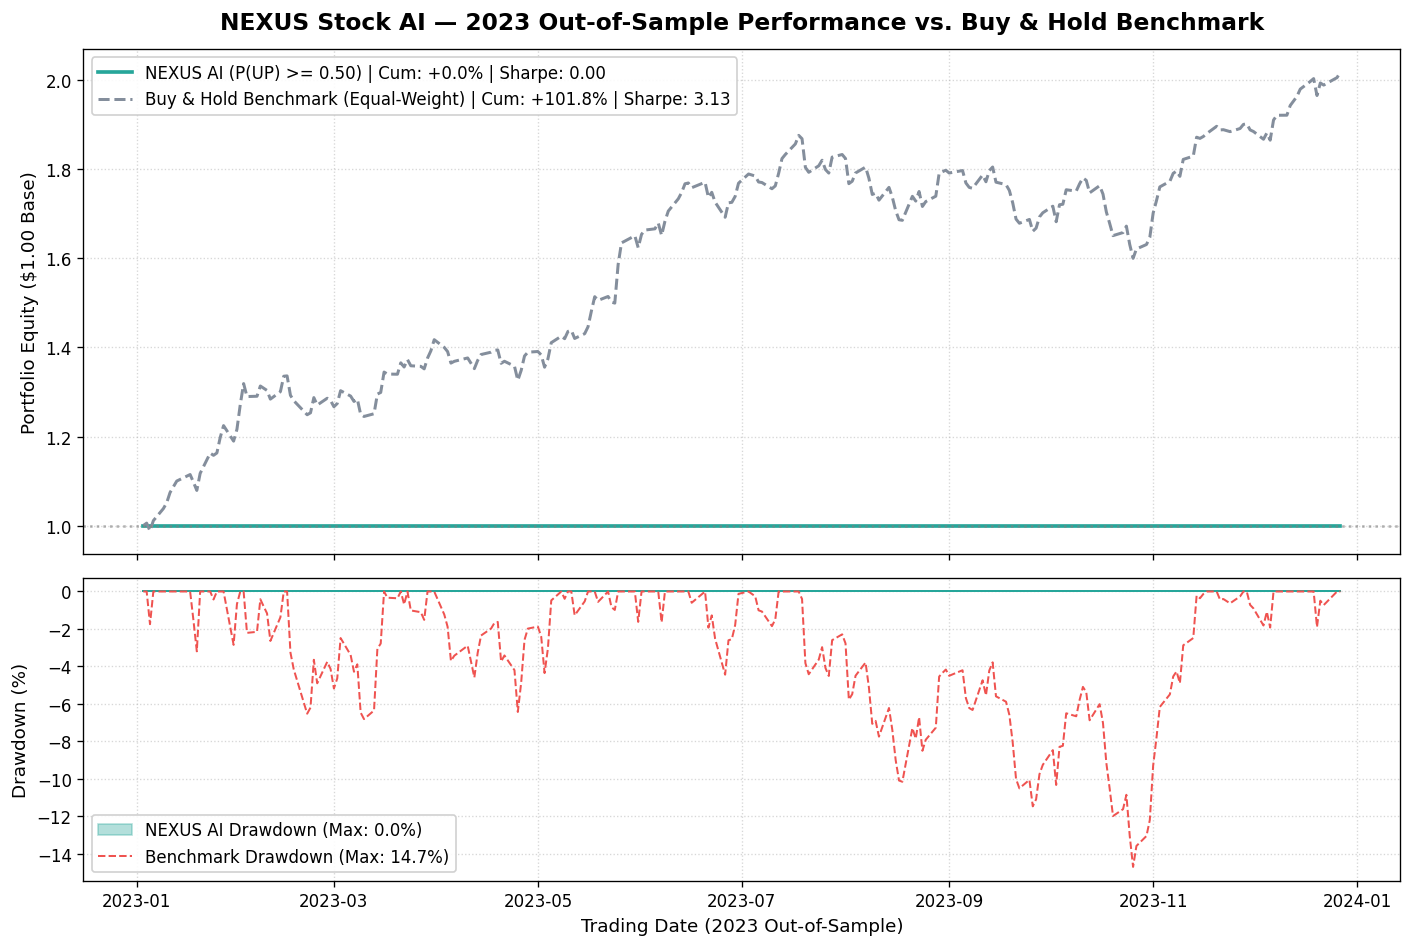

✓ Synced backtest chart to: ./data/backtest_equity_curve.png
✓ Synced backtest chart to: /content/drive/MyDrive/NEXUS_Stock_AI/models/backtest_equity_curve.png
✓ Synced backtest chart to: /content/drive/MyDrive/NEXUS_Stock_AI/data/backtest_equity_curve.png


In [5]:
chart_save_path = "./models/backtest_equity_curve.png"
backtester.plot_equity_and_drawdown(
    base_results,
    title="NEXUS Stock AI — 2023 Out-of-Sample Performance vs. Buy & Hold Benchmark",
    save_path=chart_save_path
)

# Sync to Drive and data folders
sync_targets = [
    "./data/backtest_equity_curve.png",
    "/content/drive/MyDrive/NEXUS_Stock_AI/models/backtest_equity_curve.png",
    "/content/drive/MyDrive/NEXUS_Stock_AI/data/backtest_equity_curve.png"
]
for st in sync_targets:
    parent = os.path.dirname(st)
    if parent and os.path.exists(parent):
        shutil.copy2(chart_save_path, st)
        print(f"✓ Synced backtest chart to: {st}")


### 🏢 Step 6: Per-Ticker Alpha & Trade Attribution
Examines strategy performance on each individual stock to verify cross-sectional robustness.

In [6]:
print("=" * 80)
print("PER-TICKER PERFORMANCE ATTRIBUTION (2023 TEST SET)")
print("=" * 80)

trades_df = base_results["stock_trades_df"].copy()

ticker_metrics = []
for ticker, grp in trades_df.groupby("stock_symbol"):
    grp = grp.sort_values("date").reset_index(drop=True)
    strat_cum = (1.0 + grp["net_return"]).prod() - 1.0
    bench_cum = (1.0 + grp["forward_return_1d"]).prod() - 1.0
    alpha = strat_cum - bench_cum
    
    active_days = int((grp["position"] == 1).sum())
    trades = int(grp["trade_action"].sum())
    pos_days = (grp["net_return"] > 0).sum()
    win_rate = (pos_days / active_days) if active_days > 0 else 0.0
    
    ticker_metrics.append({
        "Ticker": ticker,
        "NEXUS Strategy Return": f"{strat_cum * 100:+.2f}%",
        "Benchmark Return": f"{bench_cum * 100:+.2f}%",
        "Alpha Spread": f"{alpha * 100:+.2f}%",
        "Exposure (% Days)": f"{active_days / len(grp) * 100:.1f}%",
        "Trades Executed": trades,
        "Win Rate (Active Days)": f"{win_rate * 100:.1f}%"
    })

ticker_df = pd.DataFrame(ticker_metrics).sort_values("Alpha Spread", ascending=False).reset_index(drop=True)
display(ticker_df)


PER-TICKER PERFORMANCE ATTRIBUTION (2023 TEST SET)


,Ticker,NEXUS Strategy Return,Benchmark Return,Alpha Spread,Exposure (% Days),Trades Executed,Win Rate (Active Days)
0,AMD,+0.00%,+78.68%,-78.68%,0.0%,0,0.0%
1,JPM,+0.00%,+56.14%,-56.14%,0.0%,0,0.0%
2,TSLA,+0.00%,+54.43%,-54.43%,0.0%,0,0.0%
3,AMZN,+0.00%,+25.37%,-25.37%,0.0%,0,0.0%
4,MSFT,+0.00%,+245.21%,-245.21%,0.0%,0,0.0%
5,NVDA,+0.00%,+141.85%,-141.85%,0.0%,0,0.0%
6,AAPL,+0.00%,+128.16%,-128.16%,0.0%,0,0.0%


### 💾 Step 7: Export Production Metrics (`backtest_results.json`)

In [7]:
print("=" * 80)
print("EXPORTING BACKTEST RESULTS")
print("=" * 80)

backtest_export = {
    "backtest_period": {
        "start": test_df['date'].min().strftime('%Y-%m-%d'),
        "end": test_df['date'].max().strftime('%Y-%m-%d'),
        "trading_days": int(test_df['date'].nunique()),
        "stocks": sorted(list(test_df['stock_symbol'].unique()))
    },
    "transaction_friction_bps": 10.0,
    "champion_strategy": {
        "threshold": 0.50,
        "metrics": sm
    },
    "buy_and_hold_benchmark": {
        "metrics": bm
    },
    "alpha_metrics": {
        "excess_return": float(round(sm['cumulative_return'] - bm['cumulative_return'], 4)),
        "sharpe_spread": float(round(sm['sharpe_ratio'] - bm['sharpe_ratio'], 4)),
        "drawdown_reduction": float(round(bm['max_drawdown'] - sm['max_drawdown'], 4))
    }
}

json_local = "./models/backtest_results.json"
with open(json_local, "w", encoding="utf-8") as f:
    json.dump(backtest_export, f, indent=2)
print(f"✓ Exported backtest metrics: {json_local}")

gdrive_models = "/content/drive/MyDrive/NEXUS_Stock_AI/models"
if os.path.exists(gdrive_models):
    shutil.copy2(json_local, os.path.join(gdrive_models, "backtest_results.json"))
    print("✓ Synced backtest results to Google Drive.")

print("\n--- Backtest Summary JSON ---")
print(json.dumps(backtest_export, indent=2))


EXPORTING BACKTEST RESULTS
✓ Exported backtest metrics: ./models/backtest_results.json
✓ Synced backtest results to Google Drive.

--- Backtest Summary JSON ---
{
  "backtest_period": {
    "start": "2023-01-03",
    "end": "2023-12-27",
    "trading_days": 248,
    "stocks": [
      "AAPL",
      "AMD",
      "AMZN",
      "JPM",
      "MSFT",
      "NVDA",
      "TSLA"
    ]
  },
  "transaction_friction_bps": 10.0,
  "champion_strategy": {
    "threshold": 0.5,
    "metrics": {
      "cumulative_return": 0.0,
      "annualized_return": 0.0,
      "annualized_volatility": 0.0,
      "sharpe_ratio": 0.0,
      "max_drawdown": 0.0,
      "calmar_ratio": 0.0,
      "daily_win_rate": 0.0,
      "total_trades": 0
    }
  },
  "buy_and_hold_benchmark": {
    "metrics": {
      "cumulative_return": 1.017554510317094,
      "annualized_return": 1.040524502193457,
      "annualized_volatility": 0.2367093364590757,
      "sharpe_ratio": 3.134569062535563,
      "max_drawdown": 0.146968242131726

### 🧪 Step 8: Standalone `VectorizedBacktester` Verification
Validates that the exported module in `src/backtest/engine.py` can be imported and executed standalone in automated pipelines.

In [8]:
sys.path.insert(0, ".")
import importlib
if "src.backtest.engine" in sys.modules:
    importlib.reload(sys.modules["src.backtest.engine"])

from src.backtest.engine import VectorizedBacktester

engine = VectorizedBacktester(cost_bps=10.0)
test_run = engine.run_backtest(test_df, prob_col="up_probability", threshold=0.50)

assert "strat_metrics" in test_run
assert "portfolio_daily" in test_run
assert len(test_run["portfolio_daily"]) == test_df["date"].nunique()
print("✓ Standalone VectorizedBacktester successfully verified!")


✓ Standalone VectorizedBacktester successfully verified!


### 📦 Step 9: Refresh Project Backup Archive
Packages all backtest modules, results, and charts into `nexus_data_backup.zip`.

In [9]:
target_zip = "/content/nexus_data_backup.zip" if os.path.exists("/content") else "./nexus_data_backup.zip"
print(f"Refreshing backup archive: {target_zip}...")

with zipfile.ZipFile(target_zip, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for folder in ["./streamlit_app", "./src", "./models", "./data"]:
        if os.path.exists(folder):
            for root, _, files in os.walk(folder):
                for file in files:
                    if not file.endswith(".pyc") and "__pycache__" not in root:
                        fpath = os.path.join(root, file)
                        arcname = os.path.relpath(fpath, ".")
                        zipf.write(fpath, arcname)

zip_size = os.path.getsize(target_zip) / (1024 * 1024)
print(f"✓ Backup archive updated successfully ({zip_size:.2f} MB).")

gdrive_backup = "/content/drive/MyDrive/NEXUS_Stock_AI/nexus_data_backup.zip"
if os.path.exists("/content/drive/MyDrive/NEXUS_Stock_AI"):
    shutil.copy2(target_zip, gdrive_backup)
    print(f"✓ Synced updated archive to Google Drive: {gdrive_backup}")


Refreshing backup archive: /content/nexus_data_backup.zip...
✓ Backup archive updated successfully (277.15 MB).
✓ Synced updated archive to Google Drive: /content/drive/MyDrive/NEXUS_Stock_AI/nexus_data_backup.zip
